# Consumer Complaint Classification

In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import warnings
warnings.filterwarnings("ignore")

 

##  Load Dataset

In [1]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [2]:
# Dataset Shape
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (162421, 3)


In [3]:
# First 5 Rows
df.head(10)

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
5,5,credit_reporting,payment history missing credit report made mis...
6,6,credit_reporting,va date complaint experian credit bureau invol...
7,7,credit_reporting,account reported abbreviated name full name se...
8,8,credit_reporting,account reported abbreviated name full name se...
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...


In [4]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  162421 non-null  int64 
 1   product     162421 non-null  object
 2   narrative   162411 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.7+ MB


In [5]:
# Missing Values
df.isnull().sum()

Unnamed: 0     0
product        0
narrative     10
dtype: int64

In [6]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


##  Exploratory Data Analysis (EDA)

In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df = df.dropna()

print(df.shape)

(162411, 2)


In [9]:
df.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [10]:
print("Number of Categories:", df["product"].nunique())

print(df["product"].unique())

Number of Categories: 5
['credit_card' 'retail_banking' 'credit_reporting' 'mortgages_and_loans'
 'debt_collection']


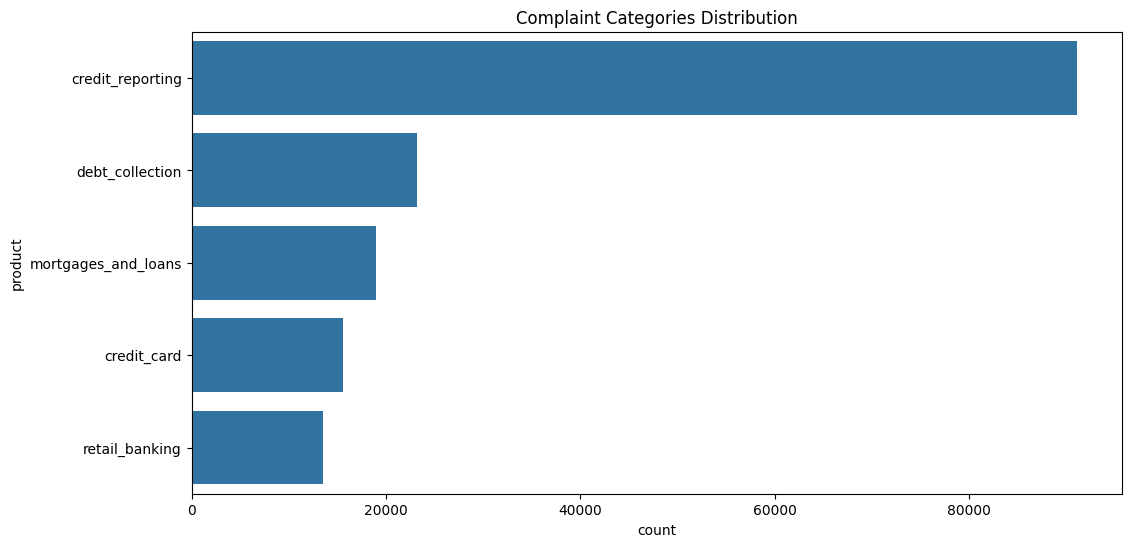

In [13]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df["product"],
    order=df["product"].value_counts().index
)

plt.title("Complaint Categories Distribution")
plt.show()

In [14]:
distribution = (
    df["product"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

distribution

product
credit_reporting       56.14
debt_collection        14.25
mortgages_and_loans    11.69
credit_card             9.58
retail_banking          8.33
Name: proportion, dtype: float64

In [15]:
df["word_count"] = df["narrative"].apply(lambda x: len(x.split()))

In [16]:
df["word_count"].describe()

count    162411.000000
mean         80.232798
std         108.872213
min           1.000000
25%          27.000000
50%          50.000000
75%          95.000000
max        2685.000000
Name: word_count, dtype: float64

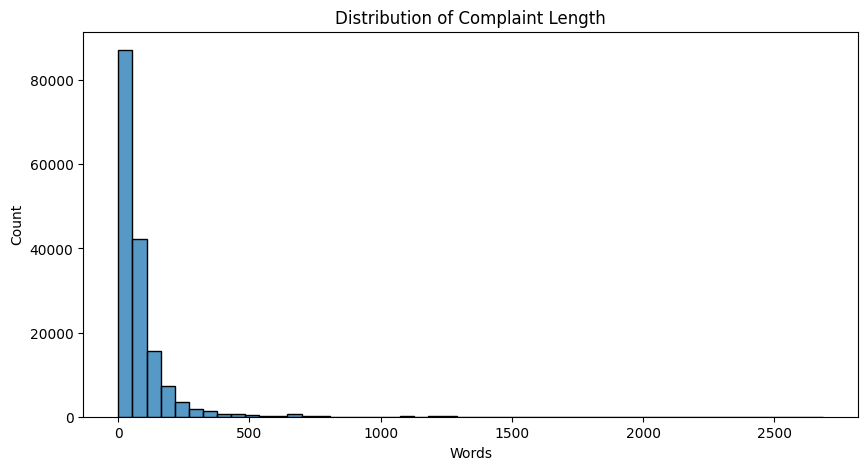

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df["word_count"], bins=50)

plt.title("Distribution of Complaint Length")
plt.xlabel("Words")
plt.show()

In [18]:
df.loc[df["word_count"].idxmax()]

product                                     mortgages_and_loans
narrative     please refer full detail written within page p...
word_count                                                 2685
Name: 119476, dtype: object

In [19]:
df.loc[df["word_count"].idxmin()]

product       credit_reporting
narrative              account
word_count                   1
Name: 1209, dtype: object

##  Data Cleaning

In [20]:
for i in range(5):
    print(f"Sample {i+1}")
    print(df["narrative"].iloc[i])
    print("-" * 80)

Sample 1
purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharged item removing

In [21]:
df["narrative"] = (
    df["narrative"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [22]:
df = df[df["narrative"].str.len() > 0]

print(df.shape)

(162411, 3)


In [23]:
df["word_count"] = df["narrative"].apply(lambda x: len(x.split()))

In [24]:
df.drop(columns=["word_count"], inplace=True)

##  Save Clean Dataset

In [25]:
OUTPUT_PATH = "/kaggle/working/cleaned_complaints.csv"

df.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset saved to: {OUTPUT_PATH}")
print(df.shape)

Dataset saved to: /kaggle/working/cleaned_complaints.csv
(162411, 2)
